<a href="https://colab.research.google.com/github/sriranjani-vs/Unsupervised-Learning-Practice/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage,dendrogram

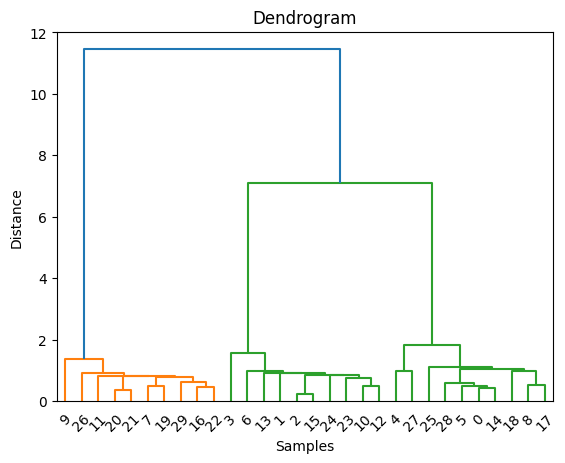

In [9]:
X, _ = make_blobs(n_samples=30, centers=3, random_state=42)
labels = AgglomerativeClustering(n_clusters=3, linkage='single').fit_predict(X)
plt.plot()
dendrogram(linkage(X,'single'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

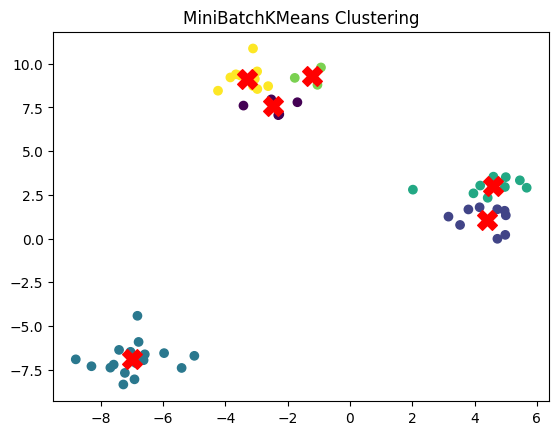

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
#Generate synthetic data
X, _ = make_blobs(n_samples=56, centers=3, n_features=2, random_state=42)
# Configure and fit MiniBatchKMeans
mbk = MiniBatchKMeans(n_clusters=6, batch_size=100, random_state=42)
mbk.fit(X)
# Visualize the results
plt.scatter(X[:, 0], X[:, 1], c=mbk.labels_, cmap='viridis')
plt.scatter(mbk.cluster_centers_[:, 0], mbk.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('MiniBatchKMeans Clustering')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#1. Load dataset
df = pd.read_csv("/content/store_customers.csv")

#2. select Features
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

# Handle missing values by dropping rows with NaN in the selected features
X = X.dropna()

#3. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#4. Apply K-means++
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

#5. Add cluster label to dataset
df_clustered = df.loc[X.index].copy()
df_clustered['cluster'] = kmeans.labels_

#6. Display the clusters centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)

#7.Display first few rows
print("\nFirst few rows of the dataset with cluster labels:")
print(df_clustered.head())

#8. Visualize clusters
plt.figure(figsize=(8, 6))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, s=50)

#plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X',label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.title('Mall customers Clustering using K-Means++')
plt.show()


Cluster Centers:
[[ 0.37991463 -0.23754623]
 [ 1.57650476 -1.6580335 ]
 [-0.76679319  0.7173392 ]]

First few rows of the dataset with cluster labels:
   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   cluster  
0        2  
1        0  
2        0  
3        0  
4        2  


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering #bottuomup approach
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import davies_bouldin_score #topdown approach

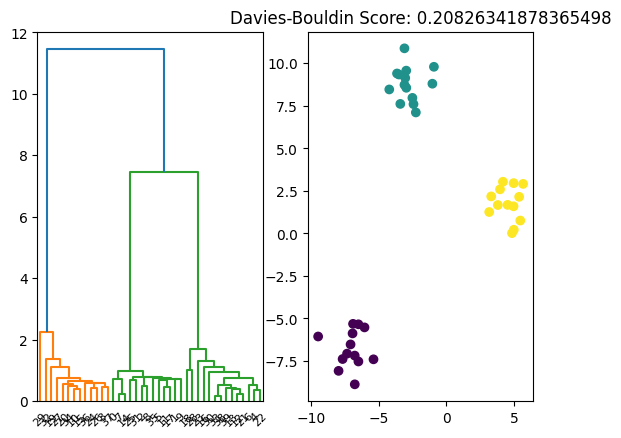

In [8]:
X,_ = make_blobs(n_samples=40,centers=3,random_state=42)
labels = AgglomerativeClustering(n_clusters=3,linkage='single').fit_predict(X)
score = davies_bouldin_score(X,labels)

plt.subplot(1,2,1)
dendrogram(linkage(X,'single'))
plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],c=labels)
plt.title(f'Davies-Bouldin Score: {score}')
plt.show()
